MORTALITY  --

BLEED  --

ARF  --

PRI --

UNPREADM -- 

UTI

PNEUMONIA ---

UNPREOP

SSSI ---

SEPSIS ---

SEPSHOCK

PPRUNPREADM

PPRUNPREOP

CAR

OSSI

PE

DSSI

DVT

STROKE

MI

WOUND


In [12]:
import os
import pickle
import pandas as pd
from typing import Dict
from datetime import datetime

from azureml.core import Workspace, Datastore, Dataset

from azureml.core import Workspace, Datastore, Dataset

ws = Workspace(
    subscription_id='f8c5aac3-29fc-4387-858a-1f61722fb57a',
    resource_group='forskerpl-n0ybkr-rg',
    workspace_name='forskerpl-n0ybkr-mlw'
)
datastore = Datastore.get(ws, 'researcher_data')
print("Ready")

Ready


In [4]:
binary_outcomes = {
    'MORTALITY': 'p1_postop/SSL/targets/MORTALITY.csv',
    'BLEED':     'p1_postop/SSL/targets/BLEED.csv',
    'ARF':       'p1_postop/SSL/targets/ARF.csv',
    'PRI':       'p1_postop/SSL/targets/PRI.csv',
}

for outcome, path in binary_outcomes.items():
    ds = Dataset.Tabular.from_delimited_files(path=(datastore, path))
    df = ds.to_pandas_dataframe()
    print(f"{outcome}: {len(df):,} positive cases ({len(df)/767161*100:.2f}%)")

Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Overriding of current MeterProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


Resolving access token for scope "https://storage.azure.com/.default" using identity of type "MANAGED".
Getting data access token with Assigned Identity (client_id=clientid) and endpoint type based on configuration
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}
MORTALITY: 9,531 positive cases (1.24%)
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}
BLEED: 20,856 positive cases (2.72%)
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}
ARF: 1,786 positive cases (0.23%)
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}
PRI: 1

In [13]:
# ============================================================
OUTCOME_NAME = "SEPSIS"
# ============================================================

import os
import pickle
import pandas as pd
from azureml.core import Workspace, Datastore, Dataset
from azure.storage.filedatalake import DataLakeServiceClient
from azure.identity import DefaultAzureCredential

# ---------- Config ----------
SUBSCRIPTION_ID  = 'f8c5aac3-29fc-4387-858a-1f61722fb57a'
RESOURCE_GROUP   = 'forskerpl-n0ybkr-rg'
WORKSPACE_NAME   = 'forskerpl-n0ybkr-mlw'
DATASTORE_NAME   = 'researcher_data'

EXPOSURE_PATH    = "p1_postop/SSL/exposure/preop.csv"
OUTCOME_PATH     = f"Zahra/062026/NewOutcomes/{OUTCOME_NAME}.csv"
MAPPING_PATH     = "Zahra/032026/Data_OOT/PreMEDS_MDPS/hash_to_integer_map.pkl"
#032026 OOT
#022026 CV
TIMESTAMP_COL    = 'time'
PID_COL          = 'subject_id'
ABSPOS_COL       = 'abspos'

FINETUNE_START   = "2020-01-01"
FINETUNE_END     = "2021-06-01"
HOLDOUT_START    = "2021-06-01"
HOLDOUT_END      = "2022-04-01"

LOCAL_DIR        = "./temp_data"
os.makedirs(LOCAL_DIR, exist_ok=True)

In [2]:
# ---------- Connect ----------
ws = Workspace(SUBSCRIPTION_ID, RESOURCE_GROUP, WORKSPACE_NAME)
datastore = Datastore.get(ws, DATASTORE_NAME)
account_name    = datastore.account_name
filesystem_name = datastore.container_name
credential      = DefaultAzureCredential()
print("Workspace loaded ✅")

Workspace loaded ✅


In [14]:
# ---------- Helper functions ----------
def read_csv_from_datastore(ws, datastore_name, path, rename_dict=None):
    ds = Datastore.get(ws, datastore_name)
    dataset = Dataset.File.from_files((ds, path))
    local_path = dataset.download("./temp", overwrite=True)[0]
    df = pd.read_csv(local_path)
    if rename_dict:
        df = df.rename(columns=rename_dict)
    return df

def load_mapping(ws, datastore_name, path):
    ds = Datastore.get(ws, datastore_name)
    dataset = Dataset.File.from_files((ds, path))
    local_path = dataset.download("./temp", overwrite=True)[0]
    with open(local_path, "rb") as f:
        return pickle.load(f)

def clean_data(df):
    return df.dropna(subset=[TIMESTAMP_COL, PID_COL]).drop_duplicates()

def map_pids(df, pid_map):
    df = df.copy()
    df[PID_COL] = df[PID_COL].astype(str).map(pid_map)
    df = df.dropna(subset=[PID_COL])
    df[PID_COL] = df[PID_COL].astype(int)
    return df

def filter_by_date(df, start, end):
    df = df.copy()
    df["parsed_time"] = pd.to_datetime(df[TIMESTAMP_COL], utc=True, errors="coerce")
    start = pd.to_datetime(start).tz_localize("UTC")
    end   = pd.to_datetime(end).tz_localize("UTC")
    df = df[(df["parsed_time"] >= start) & (df["parsed_time"] < end)]
    return df.drop(columns=["parsed_time"])

def get_hours_since_epoch(series):
    ts = pd.to_datetime(series, utc=True, errors="coerce").dt.tz_localize(None)
    return (ts.view("int64") // 10**9) / 3600

def upload_to_adls2(local_file_path, remote_file_name, directory_path):
    if not os.path.exists(local_file_path):
        raise FileNotFoundError(local_file_path)
    service_client = DataLakeServiceClient(
        account_url=f"https://{account_name}.dfs.core.windows.net",
        credential=credential
    )
    fs_client = service_client.get_file_system_client(filesystem_name)
    dir_client = fs_client.get_directory_client(directory_path)
    try:
        dir_client.create_directory()
    except:
        pass
    file_client = dir_client.get_file_client(remote_file_name)
    print(f"Uploading {remote_file_name} ...")
    with open(local_file_path, "rb") as f:
        file_client.upload_data(f, overwrite=True)
    print(f"Uploaded → {directory_path}/{remote_file_name} ✅")

In [15]:
def print_dataset_summary(exposure_df, outcome_df, title="Dataset Summary"):
    print(f"\n===== {title} =====")
    print(f"Exposure:")
    print(f"   Records: {len(exposure_df):,}")
    print(f"   Unique patients: {exposure_df[PID_COL].nunique():,}")
    print(f"Outcome:")
    print(f"   Records: {len(outcome_df):,}")
    print(f"   Unique patients: {outcome_df[PID_COL].nunique():,}")

def plot_monthly_distribution(df, timestamp_col, title):
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    df = df.copy()
    df["time_parsed"] = pd.to_datetime(df[timestamp_col], errors="coerce")
    df = df.dropna(subset=["time_parsed"])
    df["month"] = df["time_parsed"].dt.to_period("M").dt.to_timestamp()
    monthly_counts = df["month"].value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(monthly_counts.index, monthly_counts.values, width=20)
    if len(monthly_counts) > 24:
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    else:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.set_ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [16]:
# ---------- Load data ----------
exposure = read_csv_from_datastore(
    ws, DATASTORE_NAME, EXPOSURE_PATH,
    rename_dict={"PID": PID_COL, "TIMESTAMP": TIMESTAMP_COL}
)
outcome = read_csv_from_datastore(
    ws, DATASTORE_NAME, OUTCOME_PATH,
    rename_dict={"PID": PID_COL, "TIMESTAMP": TIMESTAMP_COL}
)
pid_map = load_mapping(ws, DATASTORE_NAME, MAPPING_PATH)

exposure = map_pids(clean_data(exposure), pid_map)
outcome  = map_pids(clean_data(outcome),  pid_map)
print(f"Exposure: {len(exposure):,} | Outcome: {len(outcome):,}")

{'infer_column_types': 'False', 'activity': 'download'}
{'infer_column_types': 'False', 'activity': 'download', 'activityApp': 'FileDataset'}
{'infer_column_types': 'False', 'activity': 'download'}
{'infer_column_types': 'False', 'activity': 'download', 'activityApp': 'FileDataset'}
{'infer_column_types': 'False', 'activity': 'download'}
{'infer_column_types': 'False', 'activity': 'download', 'activityApp': 'FileDataset'}
Exposure: 766,764 | Outcome: 4,471


In [17]:
# ---------- Filter & abspos ----------
exp_ft  = filter_by_date(exposure, FINETUNE_START, FINETUNE_END)
out_ft  = filter_by_date(outcome,  FINETUNE_START, FINETUNE_END)
exp_hld = filter_by_date(exposure, HOLDOUT_START,  HOLDOUT_END)
out_hld = filter_by_date(outcome,  HOLDOUT_START,  HOLDOUT_END)

for df in [exp_ft, out_ft, exp_hld, out_hld]:
    df[ABSPOS_COL] = get_hours_since_epoch(df[TIMESTAMP_COL]).astype(int)

print(f"Finetune  — Exposure: {exp_ft[PID_COL].nunique():,} | Outcome: {out_ft[PID_COL].nunique():,}")
print(f"Holdout   — Exposure: {exp_hld[PID_COL].nunique():,} | Outcome: {out_hld[PID_COL].nunique():,}")

Finetune  — Exposure: 180,947 | Outcome: 1,437
Holdout   — Exposure: 97,310 | Outcome: 717


In [18]:
for df in [exp_ft, out_ft, exp_hld, out_hld]:
    df[ABSPOS_COL] = get_hours_since_epoch(df[TIMESTAMP_COL]).astype(int)

print(f"Finetune  — Exposure: {exp_ft[PID_COL].nunique():,} | Outcome: {out_ft[PID_COL].nunique():,}")
print(f"Holdout   — Exposure: {exp_hld[PID_COL].nunique():,} | Outcome: {out_hld[PID_COL].nunique():,}")

Finetune  — Exposure: 180,947 | Outcome: 1,437
Holdout   — Exposure: 97,310 | Outcome: 717



===== SEPSIS — Finetune =====
Exposure:
   Records: 211,570
   Unique patients: 180,947
Outcome:
   Records: 1,460
   Unique patients: 1,437

===== SEPSIS — Holdout =====
Exposure:
   Records: 107,621
   Unique patients: 97,310
Outcome:
   Records: 721
   Unique patients: 717
Finetune: common=1,372, missing=65, coverage=95.48%
Holdout: common=647, missing=70, coverage=90.24%


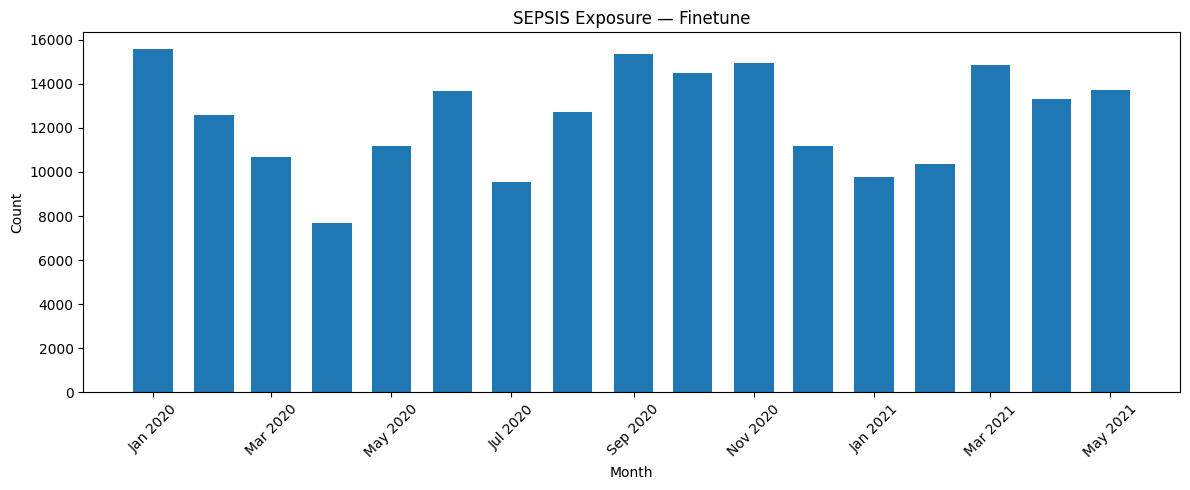

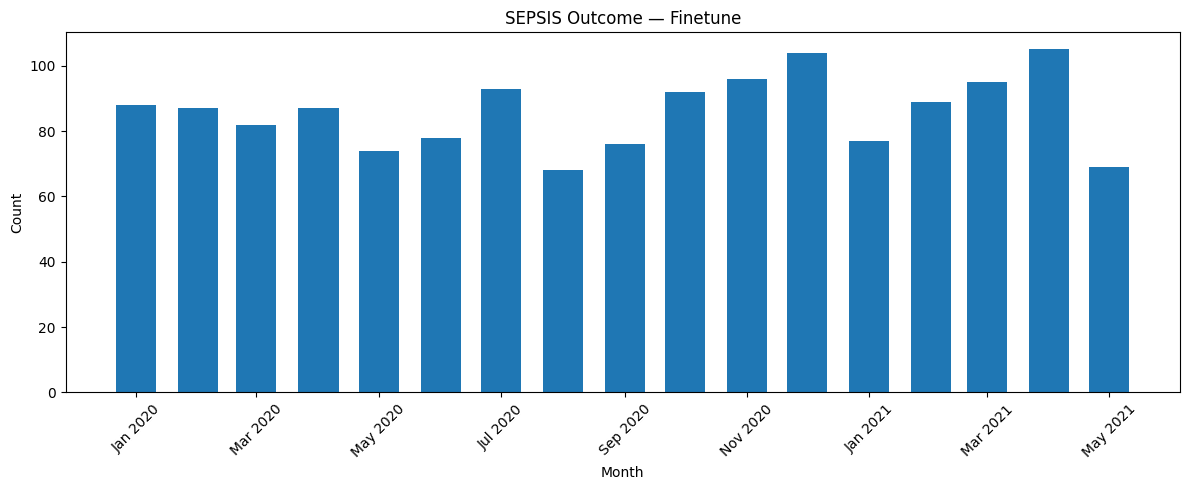

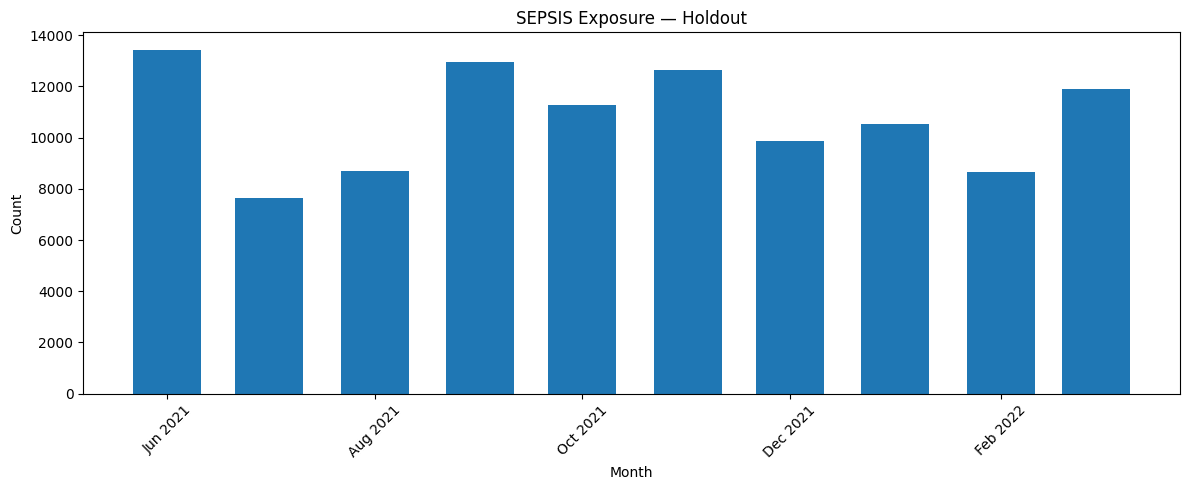

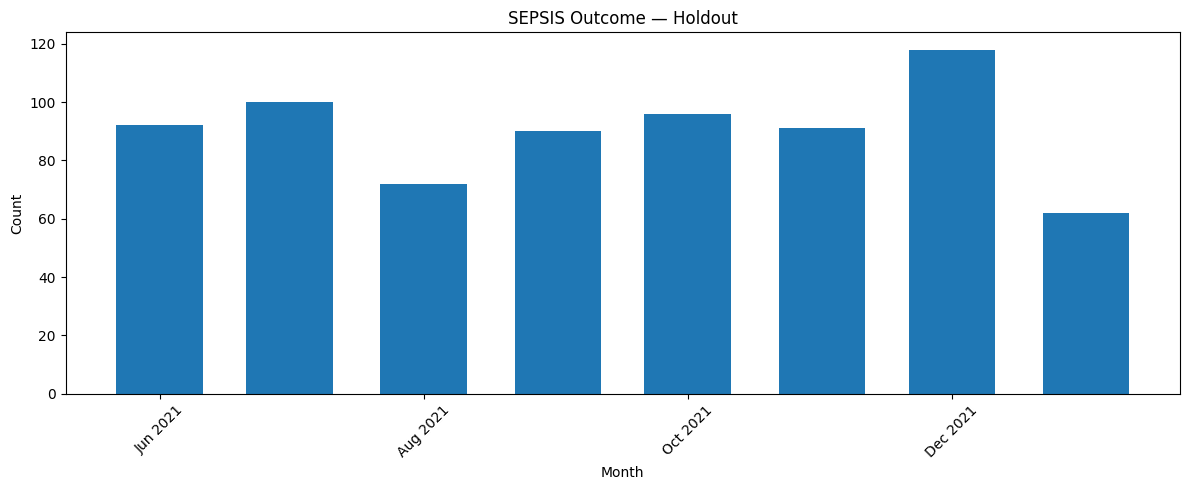

In [19]:
# ---------- Summary & Plots ----------
print_dataset_summary(exp_ft,  out_ft,  f"{OUTCOME_NAME} — Finetune")
print_dataset_summary(exp_hld, out_hld, f"{OUTCOME_NAME} — Holdout")

# Coverage check
for split_name, exp_df, out_df in [
    ("Finetune", exp_ft,  out_ft),
    ("Holdout",  exp_hld, out_hld)
]:
    exp_pids = set(exp_df[PID_COL])
    out_pids = set(out_df[PID_COL])
    common   = exp_pids.intersection(out_pids)
    missing  = out_pids - exp_pids
    coverage = len(common) / len(out_pids) if len(out_pids) > 0 else 0
    print(f"{split_name}: common={len(common):,}, missing={len(missing):,}, coverage={coverage:.2%}")

# Plots
plot_monthly_distribution(exp_ft,  TIMESTAMP_COL, f"{OUTCOME_NAME} Exposure — Finetune")
plot_monthly_distribution(out_ft,  TIMESTAMP_COL, f"{OUTCOME_NAME} Outcome — Finetune")
plot_monthly_distribution(exp_hld, TIMESTAMP_COL, f"{OUTCOME_NAME} Exposure — Holdout")
plot_monthly_distribution(out_hld, TIMESTAMP_COL, f"{OUTCOME_NAME} Outcome — Holdout")

In [20]:
print(outcome[TIMESTAMP_COL].min())
print(outcome[TIMESTAMP_COL].max())

2016-06-23
2022-01-31


In [21]:
exposure_pids = set(exp_ft[PID_COL])
outcome_pids = set(out_ft[PID_COL])
common_subjects = exposure_pids.intersection(outcome_pids)
missing_subjects = outcome_pids - exposure_pids
print("Common patients:", len(common_subjects))
print("Outcome patients WITHOUT exposure:", len(missing_subjects))
coverage = len(common_subjects) / len(outcome_pids)
print("Coverage:", coverage)

Common patients: 1372
Outcome patients WITHOUT exposure: 65
Coverage: 0.9547668754349339


In [22]:
# Coverage check
for split_name, exp_df, out_df in [
    ("Finetune", exp_ft, out_ft),
    ("Holdout",  exp_hld, out_hld)
]:
    exp_pids = set(exp_df[PID_COL])
    out_pids = set(out_df[PID_COL])
    common   = exp_pids.intersection(out_pids)
    missing  = out_pids - exp_pids
    coverage = len(common) / len(out_pids) if len(out_pids) > 0 else 0
    print(f"{split_name}: common={len(common):,}, missing={len(missing):,}, coverage={coverage:.2%}")

Finetune: common=1,372, missing=65, coverage=95.48%
Holdout: common=647, missing=70, coverage=90.24%


In [23]:
# ---------- Save & Upload ----------
files = {
    f"exposure_{OUTCOME_NAME}_finetune.csv":  (exp_ft,  f"Zahra/062026/CoreBehrt_OOT/CreateOutcome_Finetune/{OUTCOME_NAME}",  "exposure.csv"),
    f"outcome_{OUTCOME_NAME}_finetune.csv":   (out_ft,  f"Zahra/062026/CoreBehrt_OOT/CreateOutcome_Finetune/{OUTCOME_NAME}",  "outcome.csv"),
    f"exposure_{OUTCOME_NAME}_holdout.csv":   (exp_hld, f"Zahra/062026/CoreBehrt_OOT/CreateOutcome_Holdout/{OUTCOME_NAME}",   "exposure.csv"),
    f"outcome_{OUTCOME_NAME}_holdout.csv":    (out_hld, f"Zahra/062026/CoreBehrt_OOT/CreateOutcome_Holdout/{OUTCOME_NAME}",   "outcome.csv"),
}

for local_name, (df, remote_dir, remote_name) in files.items():
    local_path = os.path.join(LOCAL_DIR, local_name)
    df.to_csv(local_path, index=False)
    upload_to_adls2(local_path, remote_name, remote_dir)

Uploading exposure.csv ...
Uploaded → Zahra/062026/CoreBehrt_OOT/CreateOutcome_Finetune/SEPSIS/exposure.csv ✅
Uploading outcome.csv ...
Uploaded → Zahra/062026/CoreBehrt_OOT/CreateOutcome_Finetune/SEPSIS/outcome.csv ✅
Uploading exposure.csv ...
Uploaded → Zahra/062026/CoreBehrt_OOT/CreateOutcome_Holdout/SEPSIS/exposure.csv ✅
Uploading outcome.csv ...
Uploaded → Zahra/062026/CoreBehrt_OOT/CreateOutcome_Holdout/SEPSIS/outcome.csv ✅
